In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/steam_games_feature.csv")
df.head()


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Full audio languages,Windows,...,review_count,review_balance,price_log,owners_log,is_free,main_genre,main_category,rating_gap,release_decade,is_recent
0,Galactic Bowling,2008-10-21,0 - 20000,0,0,19.99,0,['English'],[],True,...,17,-0.277778,3.044046,9.21044,0,Casual,Single-player,0,2000,0
1,Train Bandit,2017-10-12,0 - 20000,0,0,0.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,58,0.813559,0.688135,9.21044,0,Action,Single-player,0,2010,0
2,Jolt Project,2021-11-17,0 - 20000,0,0,4.99,0,"['English', 'Portuguese - Brazil']",[],True,...,0,0.000000,1.790091,9.21044,0,Action,Single-player,0,2020,1
3,Henosis™,2020-07-23,0 - 20000,0,0,5.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,3,0.750000,1.944481,9.21044,0,Adventure,Single-player,0,2020,1
4,Two Weeks in Painland,2020-02-03,0 - 20000,0,0,0.00,0,"['English', 'Spanish - Spain']",[],True,...,58,0.711864,0.000000,9.21044,1,Adventure,Single-player,0,2020,1


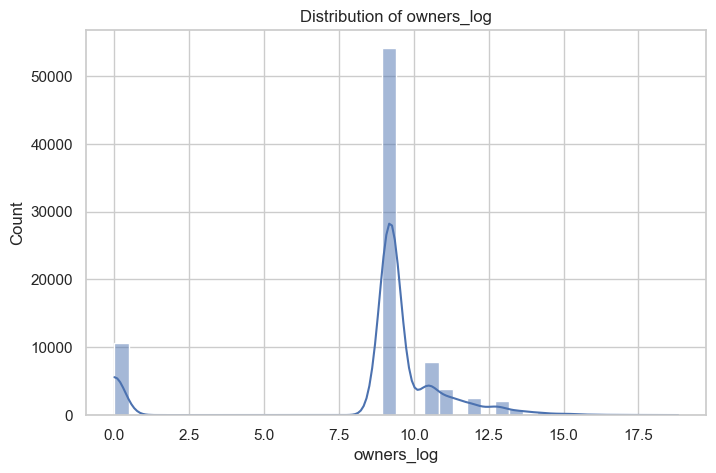

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df["owners_log"], kde=True, bins=40)
plt.title("Distribution of owners_log")
plt.show()


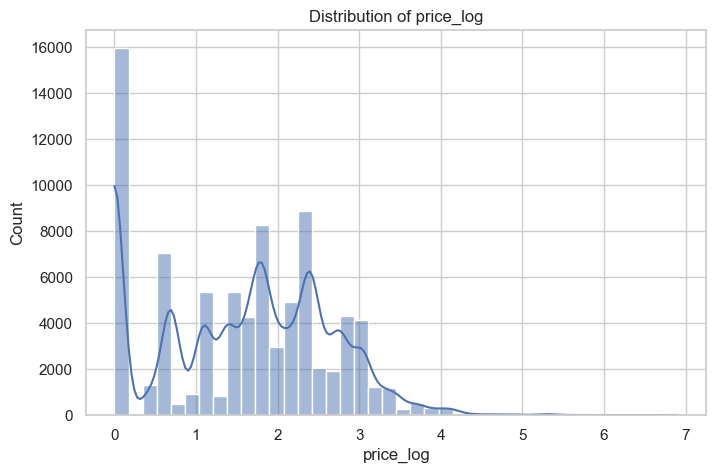

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["price_log"], kde=True, bins=40)
plt.title("Distribution of price_log")
plt.show()


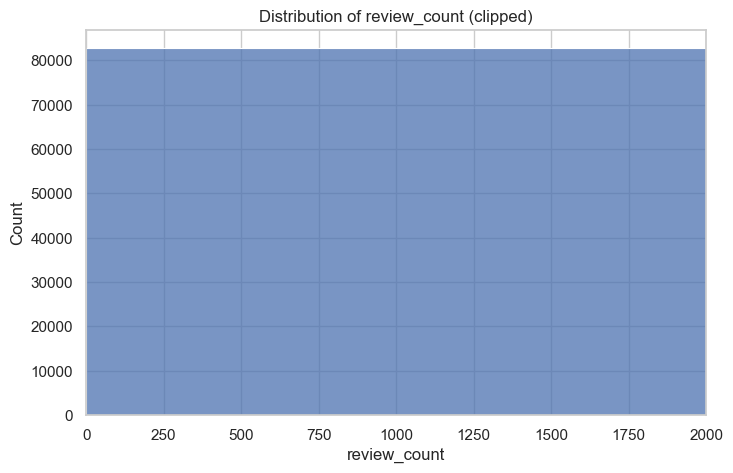

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["review_count"], kde=False, bins=50)
plt.xlim(0, 2000)  # 防止尾巴太大
plt.title("Distribution of review_count (clipped)")
plt.show()


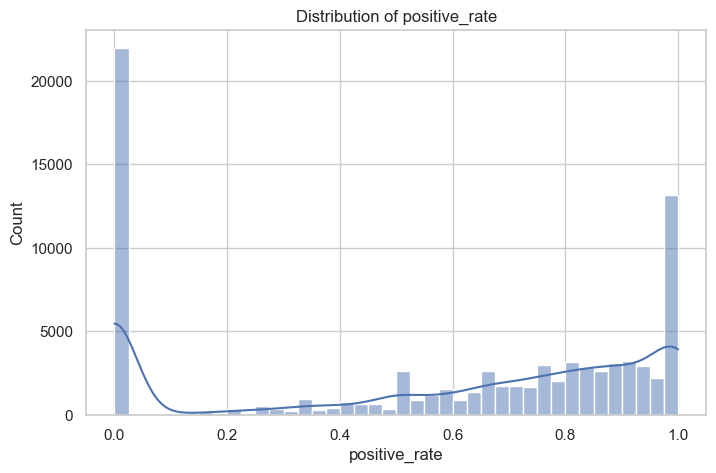

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["positive_rate"], kde=True, bins=40)
plt.title("Distribution of positive_rate")
plt.show()


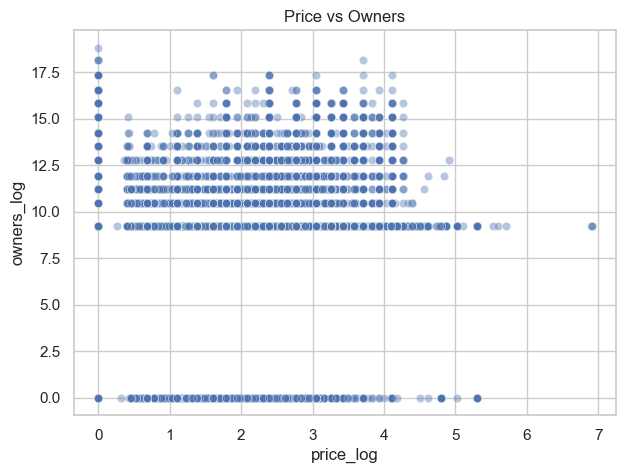

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="price_log", y="owners_log", data=df, alpha=0.4)
plt.title("Price vs Owners")
plt.show()


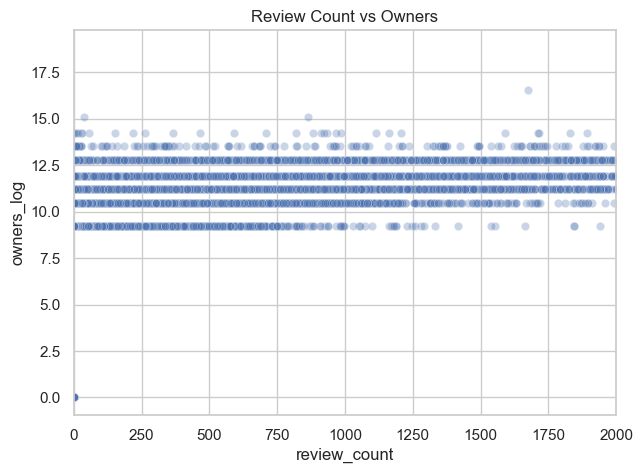

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="review_count", y="owners_log", data=df, alpha=0.3)
plt.xlim(0, 2000)
plt.title("Review Count vs Owners")
plt.show()


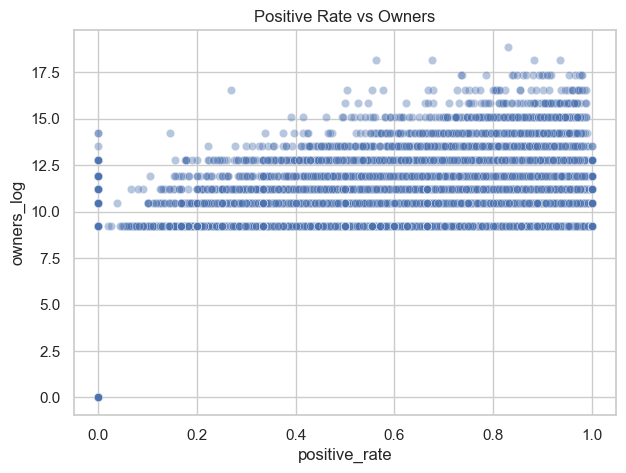

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="positive_rate", y="owners_log", data=df, alpha=0.4)
plt.title("Positive Rate vs Owners")
plt.show()


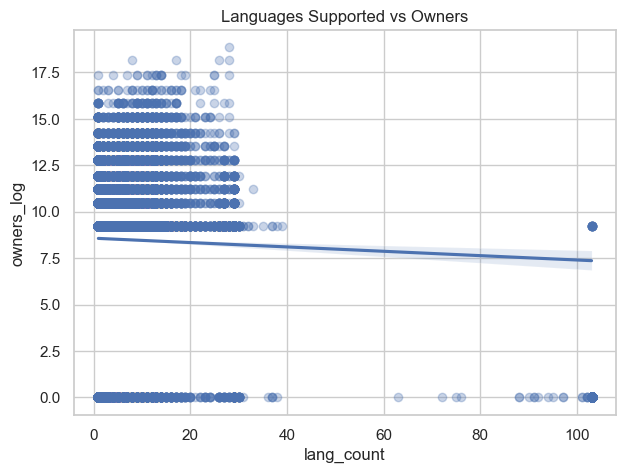

In [10]:
plt.figure(figsize=(7,5))
sns.regplot(x="lang_count", y="owners_log", data=df, scatter_kws={'alpha':0.3})
plt.title("Languages Supported vs Owners")
plt.show()


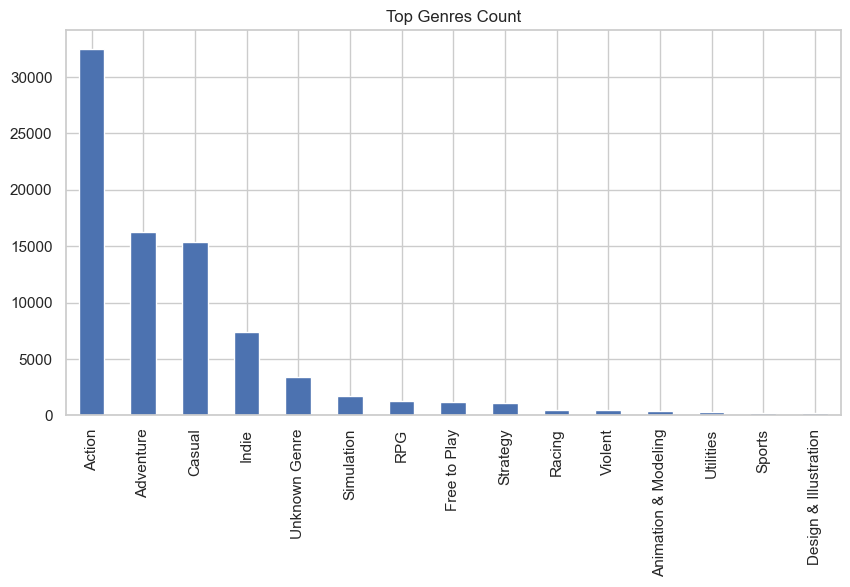

In [11]:
plt.figure(figsize=(10,5))
df["main_genre"].value_counts().head(15).plot(kind="bar")
plt.title("Top Genres Count")
plt.show()


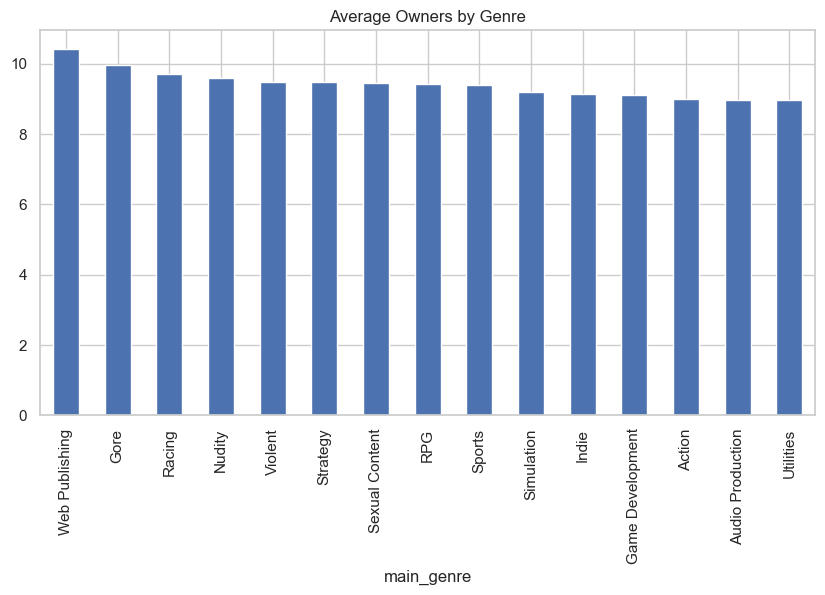

In [12]:
plt.figure(figsize=(10,5))
df.groupby("main_genre")["owners_log"].mean().sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Average Owners by Genre")
plt.show()


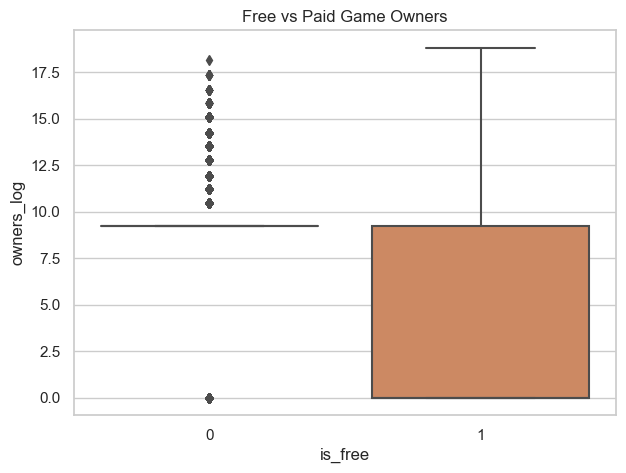

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["is_free"].astype(str), y=df["owners_log"])
plt.title("Free vs Paid Game Owners")
plt.show()


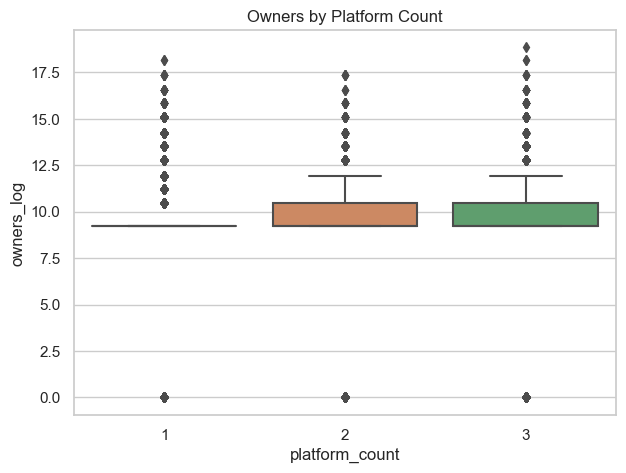

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(x="platform_count", y="owners_log", data=df)
plt.title("Owners by Platform Count")
plt.show()


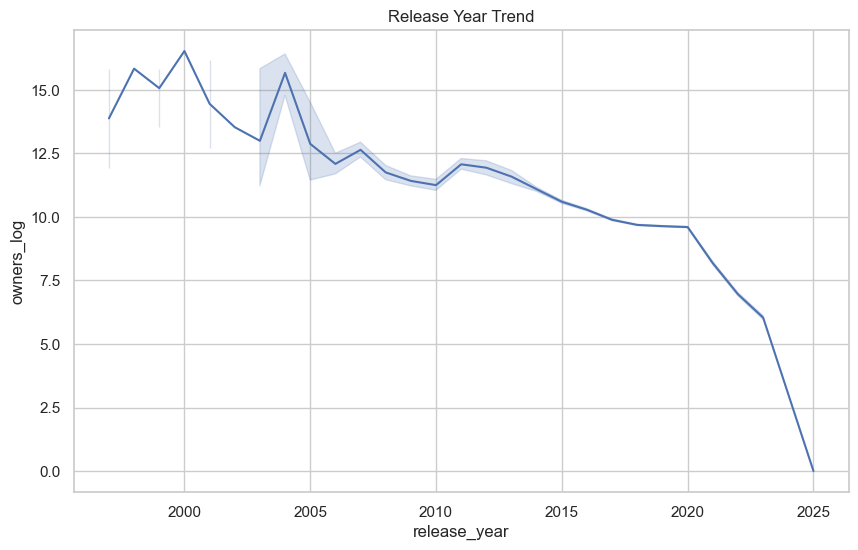

In [15]:
plt.figure(figsize=(10,6))
sns.lineplot(x="release_year", y="owners_log", data=df)
plt.title("Release Year Trend")
plt.show()


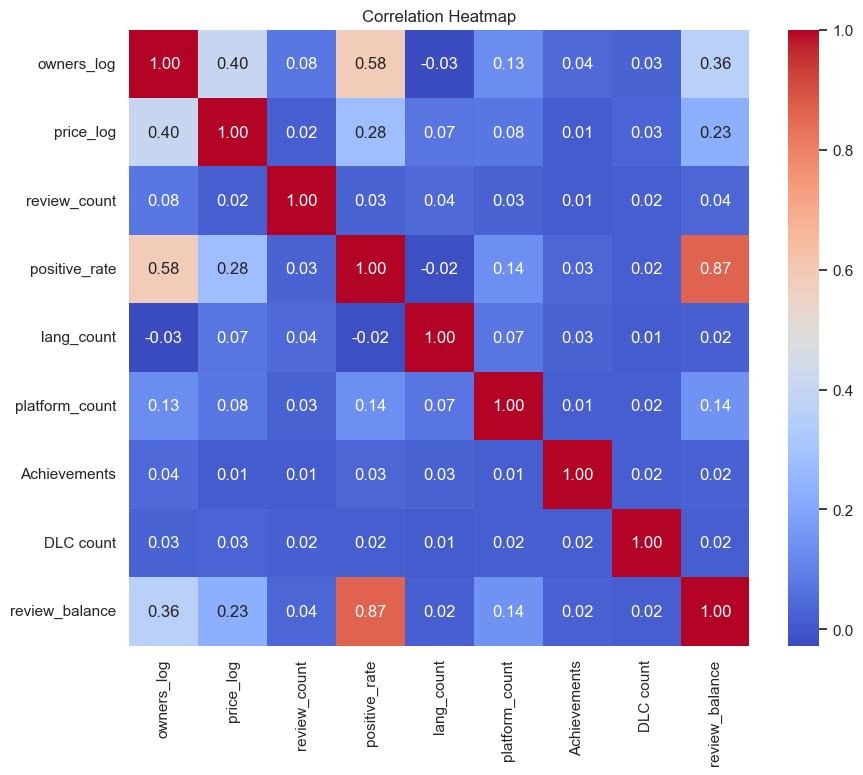

In [16]:
plt.figure(figsize=(10,8))
corr = df[["owners_log","price_log","review_count","positive_rate","lang_count",
           "platform_count","Achievements","DLC count","review_balance"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
